Samples: 4676
Intents: 34


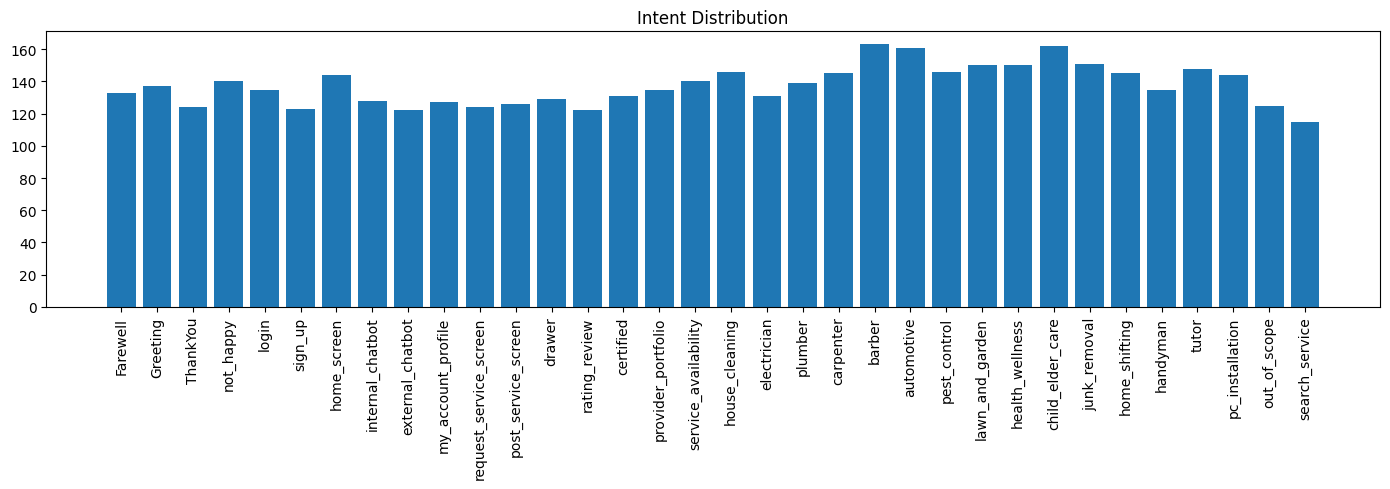

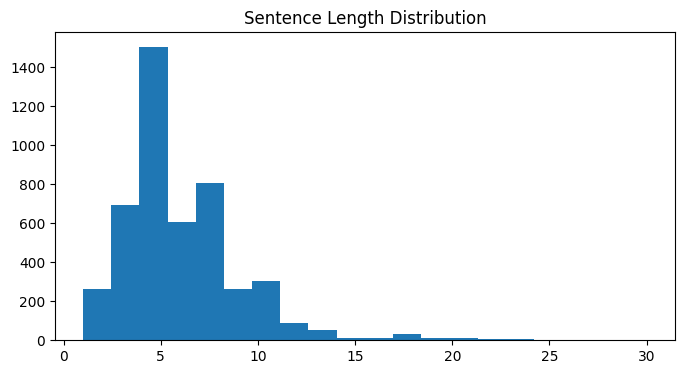

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 25, 128)        │       384,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 34)             │         1,122 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 411,970 (1.57 MB)

 Trainable params: 411,970 (1.57 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
234/234 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.0307 - loss: 3.5258 - val_accuracy: 0.0427 - val_loss: 3.5229 - learning_rate: 7.0000e-04
Epoch 2/40
234/234 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.0361 - loss: 3.5147 - val_accuracy: 0.0641 - val_loss: 3.4864 - learning_rate: 7.0000e-04
Epoch 3/40
234/234 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.0679 - loss: 3.3337 - val_accuracy: 0.1421 - val_loss: 3.0203 - learning_rate: 7.0000e-04
Epoch 4/40
234/234 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.1631 - loss: 2.7836 - val_accuracy: 0.3141 - val_loss: 2.3940 - learning_rate: 7.0000e-04
Epoch 5/40
234/234 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.2711 - loss: 2.2459 - val_accuracy: 0.3665 - val_loss: 1.9837 - learning_rate: 7.0000e-04
Epoch 6/40
234/234 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3650 - loss: 1.8931 - val_accuracy: 0.4690 - val_loss: 1.7477 - learning_rate: 7.0000e-04
Epoch 7/40
234/234 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy

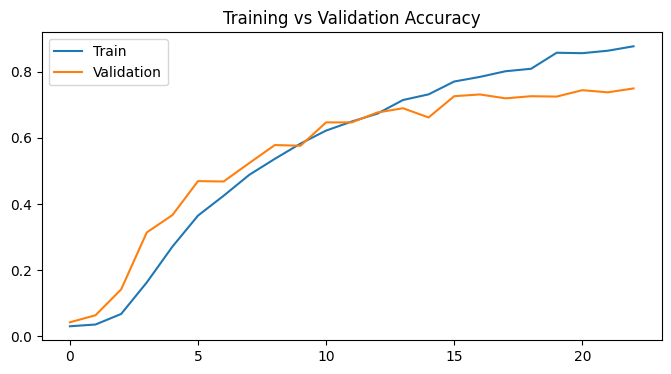

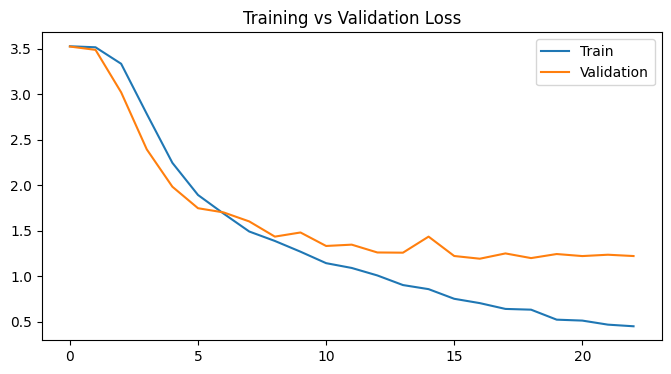

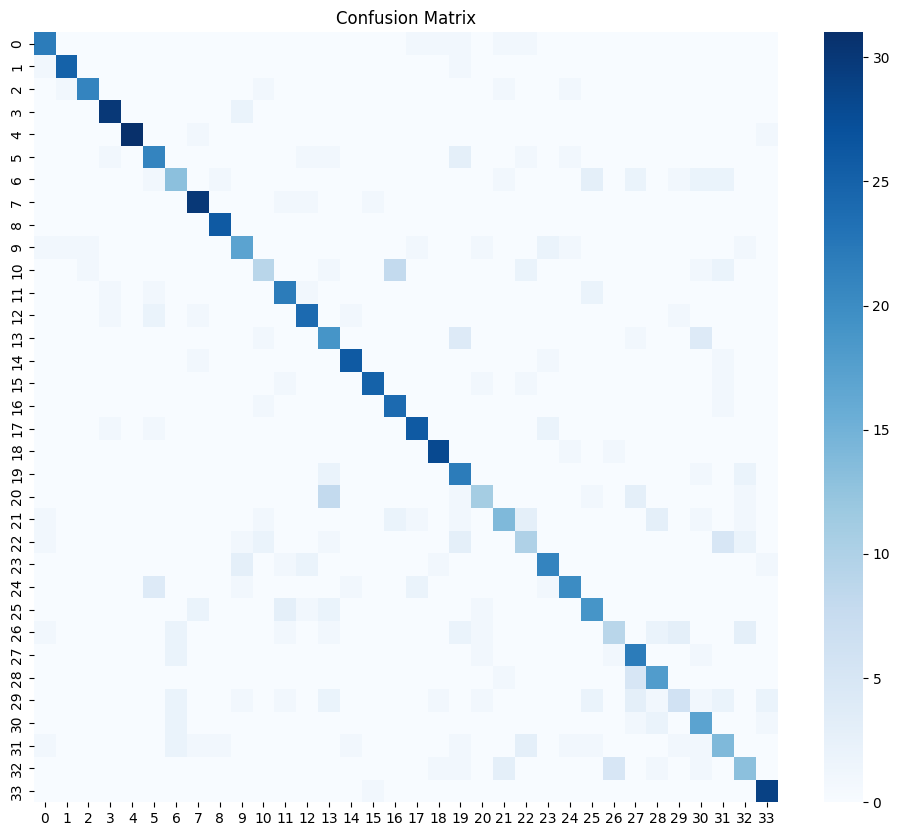

Saved artifact at '/tmp/tmp_571uroy'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 25), dtype=tf.float32, name='keras_tensor_28')
Output Type:
  TensorSpec(shape=(None, 34), dtype=tf.float32, name=None)
Captures:
  136819570429776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136819570433616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136820069201104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136820069203408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136820069200528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136820069202640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136820069200912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136820069200720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136819587213712: TensorSpec(shape=(), dtype=tf.resource, name=None)

DONE
Saved original + TFLite + zip


In [6]:
# ============================================================
# SMARTSERVE FINAL COMPLETE — BEST DENSE MODEL
# ============================================================

import json
import re
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Embedding,
    GlobalAveragePooling1D,
    Dense,
    Dropout
)

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

from tensorflow.keras.optimizers import Adam


# ============================================================
# DATASET
# ============================================================

DATA_PATH = "/content/smartserve_dataset_english_clean_v2.json"

with open(DATA_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

texts = []
labels = []
responses = {}


# ============================================================
# CLEAN
# ============================================================

def clean_text(text):

    text = text.lower().strip()

    text = re.sub(r"[^\w\s]", "", text)

    text = re.sub(r"\s+", " ", text)

    return text


# ============================================================
# READ
# ============================================================

for item in data["intents"]:

    intent = item["intent"]

    responses[intent] = item["responses"]

    for sentence in item["text"]:

        cleaned = clean_text(sentence)

        if cleaned != "":

            texts.append(cleaned)

            labels.append(intent)

print("Samples:", len(texts))
print("Intents:", len(set(labels)))


# ============================================================
# INTENT DISTRIBUTION
# ============================================================

intent_counts = {}

for item in labels:

    if item not in intent_counts:
        intent_counts[item] = 0

    intent_counts[item] += 1

plt.figure(figsize=(14, 5))

plt.bar(
    intent_counts.keys(),
    intent_counts.values()
)

plt.xticks(rotation=90)

plt.title("Intent Distribution")

plt.tight_layout()

plt.show()


# ============================================================
# TOKENIZER
# ============================================================

VOCAB_SIZE = 3000
MAX_LEN = 25

tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(texts)

sequences = tokenizer.texts_to_sequences(texts)

padded = pad_sequences(
    sequences,
    maxlen=MAX_LEN,
    padding="post"
)


# ============================================================
# SENTENCE LENGTH
# ============================================================

lengths = []

for s in sequences:
    lengths.append(len(s))

plt.figure(figsize=(8, 4))

plt.hist(lengths, bins=20)

plt.title("Sentence Length Distribution")

plt.show()


# ============================================================
# LABELS
# ============================================================

label_encoder = LabelEncoder()

encoded_labels = label_encoder.fit_transform(labels)

num_classes = len(label_encoder.classes_)


# ============================================================
# SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    padded,
    encoded_labels,
    test_size=0.20,
    random_state=42,
    stratify=encoded_labels
)


# ============================================================
# MODEL
# ============================================================

model = Sequential([

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=128
    ),

    GlobalAveragePooling1D(),

    Dense(
        128,
        activation="relu"
    ),

    Dropout(0.45),

    Dense(
        64,
        activation="relu"
    ),

    Dropout(0.30),

    Dense(
        32,
        activation="relu"
    ),

    Dense(
        num_classes,
        activation="softmax"
    ),
])

model.build(
    input_shape=(None, MAX_LEN)
)

model.summary()


# ============================================================
# COMPILE
# ============================================================

model.compile(

    optimizer=Adam(
        learning_rate=0.0007
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"],
)


# ============================================================
# CALLBACKS
# ============================================================

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True,
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1,
)


# ============================================================
# TRAIN
# ============================================================

history = model.fit(

    X_train,
    y_train,

    validation_data=(
        X_test,
        y_test,
    ),

    epochs=40,

    batch_size=16,

    callbacks=[
        early_stop,
        reduce_lr,
    ],
)


# ============================================================
# PREDICT
# ============================================================

y_pred_probs = model.predict(X_test)

y_pred = np.argmax(
    y_pred_probs,
    axis=1
)


# ============================================================
# METRICS
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print()
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

print()

print(classification_report(
    y_test,
    y_pred
))


# ============================================================
# ACCURACY GRAPH
# ============================================================

plt.figure(figsize=(8, 4))

plt.plot(
    history.history["accuracy"],
    label="Train"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation"
)

plt.legend()

plt.title(
    "Training vs Validation Accuracy"
)

plt.show()


# ============================================================
# LOSS GRAPH
# ============================================================

plt.figure(figsize=(8, 4))

plt.plot(
    history.history["loss"],
    label="Train"
)

plt.plot(
    history.history["val_loss"],
    label="Validation"
)

plt.legend()

plt.title(
    "Training vs Validation Loss"
)

plt.show()


# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(12, 10))

sns.heatmap(
    cm,
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.show()


# ============================================================
# SAVE + TFLITE
# ============================================================

BASE_DIR = "/content/smartserve_export"

ORIGINAL_DIR = os.path.join(
    BASE_DIR,
    "original_model"
)

TFLITE_DIR = os.path.join(
    BASE_DIR,
    "tflite_model"
)

os.makedirs(
    ORIGINAL_DIR,
    exist_ok=True
)

os.makedirs(
    TFLITE_DIR,
    exist_ok=True
)

tokenizer_json = tokenizer.to_json()

for folder in [ORIGINAL_DIR, TFLITE_DIR]:

    with open(
        f"{folder}/tokenizer.json",
        "w"
    ) as f:
        f.write(tokenizer_json)

    with open(
        f"{folder}/classes.txt",
        "w"
    ) as f:

        for item in label_encoder.classes_:
            f.write(item + "\n")

    config = {
        "MAX_LEN": MAX_LEN,
        "VOCAB_SIZE": VOCAB_SIZE
    }

    with open(
        f"{folder}/config.json",
        "w"
    ) as f:
        json.dump(config, f)

    with open(
        f"{folder}/intent_responses.json",
        "w"
    ) as f:
        json.dump(responses, f)

model.save(
    f"{ORIGINAL_DIR}/smartserve_model.keras"
)

converter = tf.lite.TFLiteConverter.from_keras_model(
    model
)

converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS
]

converter.inference_input_type = tf.float32

converter.inference_output_type = tf.float32

tflite_model = converter.convert()

with open(
    f"{TFLITE_DIR}/smartserve_model.tflite",
    "wb"
) as f:
    f.write(tflite_model)

shutil.make_archive(
    "/content/original_model_zip",
    "zip",
    ORIGINAL_DIR
)

shutil.make_archive(
    "/content/tflite_model_zip",
    "zip",
    TFLITE_DIR
)

print()
print("DONE")
print("Saved original + TFLite + zip")

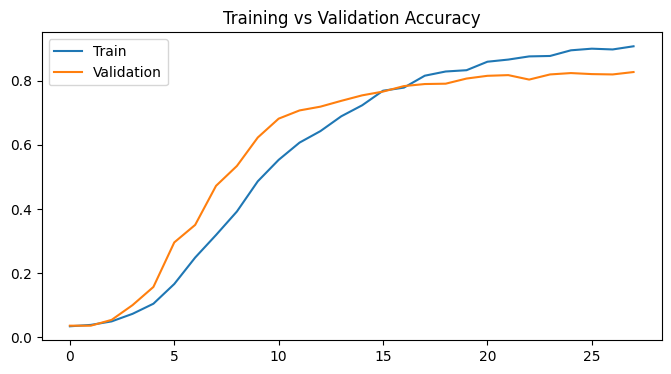

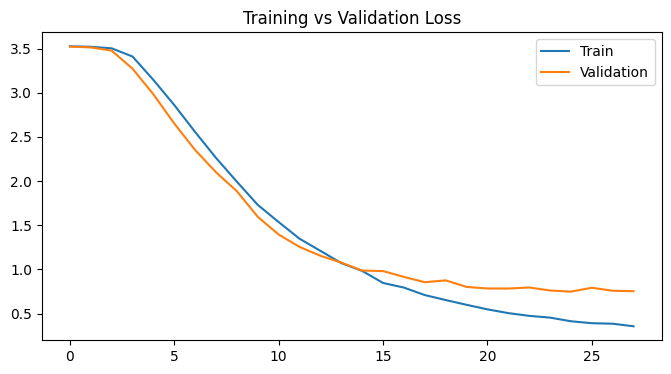

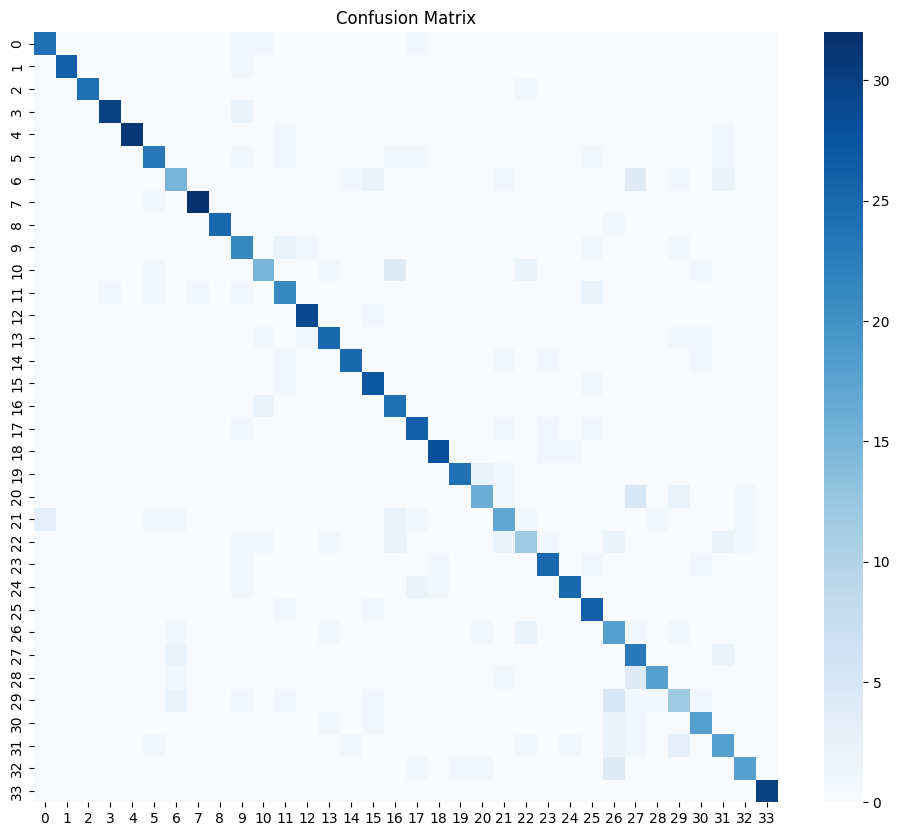

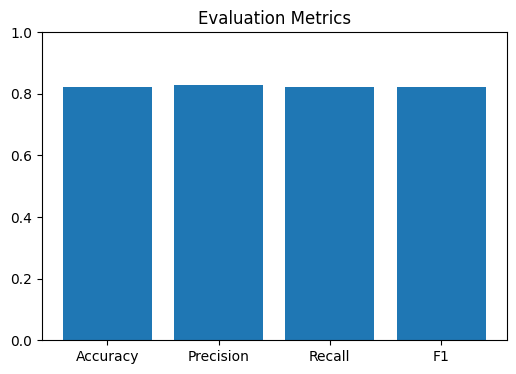

In [ ]:
# ============================================================
# SMARTSERVE AI — PART 2
# VISUALIZATIONS
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix



# ============================================================
# ACCURACY
# ============================================================

plt.figure(figsize=(8,4))

plt.plot(
    history.history["accuracy"],
    label="Train"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation"
)

plt.legend()

plt.title("Training vs Validation Accuracy")

plt.show()

# ============================================================
# LOSS
# ============================================================

plt.figure(figsize=(8,4))

plt.plot(
    history.history["loss"],
    label="Train"
)

plt.plot(
    history.history["val_loss"],
    label="Validation"
)

plt.legend()

plt.title("Training vs Validation Loss")

plt.show()

# ============================================================
# CONFUSION
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.show()

# ============================================================
# METRICS BAR
# ============================================================

plt.figure(figsize=(6,4))

plt.bar(
    ["Accuracy","Precision","Recall","F1"],
    [accuracy, precision, recall, f1]
)

plt.ylim(0,1)

plt.title("Evaluation Metrics")

plt.show()

In [ ]:
# ============================================================
# SMARTSERVE AI — PART 3
# SAVE + ZIP + TFLITE
# ============================================================

import os
import shutil

BASE_DIR = "/content/smartserve_export"

ORIGINAL_DIR = os.path.join(
    BASE_DIR,
    "original_model"
)

TFLITE_DIR = os.path.join(
    BASE_DIR,
    "tflite_model"
)

os.makedirs(
    ORIGINAL_DIR,
    exist_ok=True
)

os.makedirs(
    TFLITE_DIR,
    exist_ok=True
)

# ============================================================
# TOKENIZER
# ============================================================

tokenizer_json = tokenizer.to_json()

for folder in [ORIGINAL_DIR, TFLITE_DIR]:

    with open(
        f"{folder}/tokenizer.json",
        "w"
    ) as f:
        f.write(tokenizer_json)

    with open(
        f"{folder}/classes.txt",
        "w"
    ) as f:

        for item in label_encoder.classes_:
            f.write(item + "\n")

    config = {
        "MAX_LEN": MAX_LEN,
        "VOCAB_SIZE": VOCAB_SIZE
    }

    with open(
        f"{folder}/config.json",
        "w"
    ) as f:
        json.dump(config, f)

    with open(
        f"{folder}/intent_responses.json",
        "w"
    ) as f:
        json.dump(responses, f)

# ============================================================
# SAVE KERAS
# ============================================================

model.save(
    f"{ORIGINAL_DIR}/smartserve_model.keras"
)

# ============================================================
# TFLITE
# ============================================================

converter = tf.lite.TFLiteConverter.from_keras_model(model)

converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS
]

converter.inference_input_type = tf.float32
converter.inference_output_type = tf.float32

tflite_model = converter.convert()

with open(
    f"{TFLITE_DIR}/smartserve_model.tflite",
    "wb"
) as f:
    f.write(tflite_model)

# ============================================================
# ZIP
# ============================================================

shutil.make_archive(
    "/content/original_model_zip",
    "zip",
    ORIGINAL_DIR
)

shutil.make_archive(
    "/content/tflite_model_zip",
    "zip",
    TFLITE_DIR
)

print()
print("DONE")
print("Saved original + TFLite + zip")

Saved artifact at '/tmp/tmps9vndmo3'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 25), dtype=tf.float32, name='keras_tensor_160')
Output Type:
  TensorSpec(shape=(None, 34), dtype=tf.float32, name=None)
Captures:
  133562271959376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133562210798480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133562210810000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133562210807696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133562210805392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133562210811728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133562210805776: TensorSpec(shape=(), dtype=tf.resource, name=None)

DONE
Saved original + TFLite + zip
